### Justification Empirical Investigation 
- show shift in liqyuidity for different pairs and liquidity contraction
- Cost Curve/ Distribution

In [177]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [178]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from cfmm_routing.sbm import (
    SBMGenerator,
    RoleSBMConfig,
    TopologyModel,
    NodeAttributeRule,
    NodeAttributeModel,
    EdgeAttributeRule,
    EdgeAttributeModel,
)

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [179]:
role_cfg = RoleSBMConfig(
    n_nodes=50,
    role_probs={
        "core": 0.08,
        "mid": 0.17,
        "periphery": 0.75
    },
    role_connectivity={
        ("core","core"): 0.6,
        ("core","mid"): 0.35,
        ("core","periphery"): 0.15,
        ("mid","mid"): 0.08,
        ("mid","periphery"): 0.04,
        ("periphery","periphery"): 0.005
    },
    degree_correction=True,
    pareto_alpha=2.5,
    seed=7
)

topology_model = TopologyModel(role_cfg)

In [180]:
def token_type_sampler(node, G, rng):
    role = G.nodes[node]["role"]


    ### TO-DO: ADJUST TO 2 TOKEN GROUPS (ATRRIBUITES ) / 2 NODE GROUPS (TYPOLOGY)
    conditional_probs = {
        "core": {"stable":0.45, "major":0.45, "alt":0.1, "meme":0.0},
        "mid": {"stable":0.1, "major":0.4, "alt":0.4, "meme":0.1},
        "periphery": {"stable":0.02, "major":0.08, "alt":0.55, "meme":0.35}
    }

    types = list(conditional_probs[role].keys())
    probs = np.array(list(conditional_probs[role].values()))
    probs /= probs.sum()

    return rng.choice(types, p=probs)

node_rules = {
    "token_type": NodeAttributeRule("token_type", token_type_sampler)
}

node_model = NodeAttributeModel(node_rules, seed=11)

In [ ]:
def amm_sampler(i, j, G, rng):
    ti = G.nodes[i]["token_type"]
    tj = G.nodes[j]["token_type"]

    # Example logic
    if ti == "stable" and tj == "stable":
        return rng.choice(["curve", "univ2"], p=[0.9, 0.1])

    return "univ2"


def liquidity_sampler(i, j, G, rng):
    ri = G.nodes[i]["role"]
    rj = G.nodes[j]["role"]

    base = {
        "core": 5e6,
        "mid": 1e6,
        "periphery": 2e5
    }

    scale = (base[ri] + base[rj]) / 2
    return scale * rng.lognormal(mean=0, sigma=0.6)


def fee_sampler(i, j, G, rng):
    return rng.integers(1, 51) / 1000  # 0.001..0.050 step 0.001
def A_sampler(i, j, G, rng):
    if G.edges[i, j]["amm"] == "curve":
        return int(rng.uniform(500, 2000))
    return None

def bal_weight_sampler(i, j, G, rng):
    ti = G.nodes[i]["token_type"]
    tj = G.nodes[j]["token_type"]

    if ti == "stable" and tj == "stable":
        return (0.5, 0.5)

    w = round(rng.uniform(0.2, 0.8),1)
    return (w, 1 - w)



edge_rules = {
    "amm": EdgeAttributeRule("amm", amm_sampler),
    "liquidity": EdgeAttributeRule("liquidity", liquidity_sampler),
    "fee": EdgeAttributeRule("fee", fee_sampler),
    "A": EdgeAttributeRule("A", A_sampler),
    # "bal_weights": EdgeAttributeRule("bal_weights", bal_weight_sampler),
}

edge_model = EdgeAttributeModel(edge_rules, seed=22)

In [192]:
generator = SBMGenerator(
    topology_model=topology_model,
    node_model=node_model,
    edge_model=edge_model
)

G = generator.generate()

# --- Compute connected components
comp_id = {}
for k, comp in enumerate(nx.connected_components(G)):
    for node in comp:
        comp_id[node] = k

def reachable(i, j):
    return comp_id[i] == comp_id[j]

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 50
Edges: 53


Average degree: 2.12
Max degree: 14


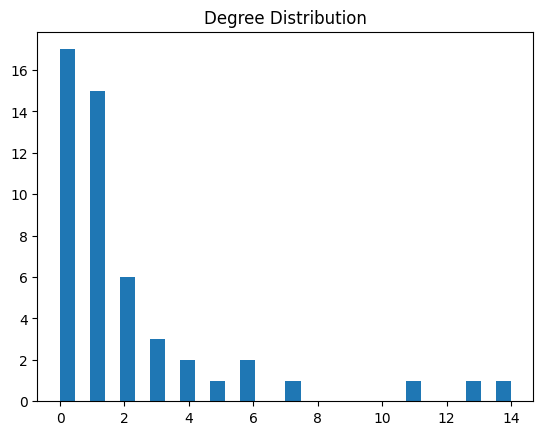

Role counts: {'mid': 8, 'core': 5, 'periphery': 37}
0 21 {'amm': 'univ2', 'liquidity': 259396.7130366766, 'fee': np.float64(0.033), 'A': None}
3 6 {'amm': 'univ2', 'liquidity': 1373347.080937112, 'fee': np.float64(0.01), 'A': None}
3 23 {'amm': 'univ2', 'liquidity': 2064733.30601263, 'fee': np.float64(0.001), 'A': None}
3 24 {'amm': 'univ2', 'liquidity': 1147773.47121289, 'fee': np.float64(0.023), 'A': None}
4 23 {'amm': 'univ2', 'liquidity': 4580889.180917159, 'fee': np.float64(0.016), 'A': None}


In [193]:
# diagnostics 
degrees = np.array([d for _, d in G.degree()])

print("Average degree:", degrees.mean())
print("Max degree:", degrees.max())

plt.hist(degrees, bins=30)
plt.title("Degree Distribution")
plt.show()

roles = nx.get_node_attributes(G, "role")
print("Role counts:",
      {r: list(roles.values()).count(r) for r in set(roles.values())})


for (i, j, data) in list(G.edges(data=True))[:5]:
    print(i, j, data)

Original nodes: 50
LCC nodes: 33


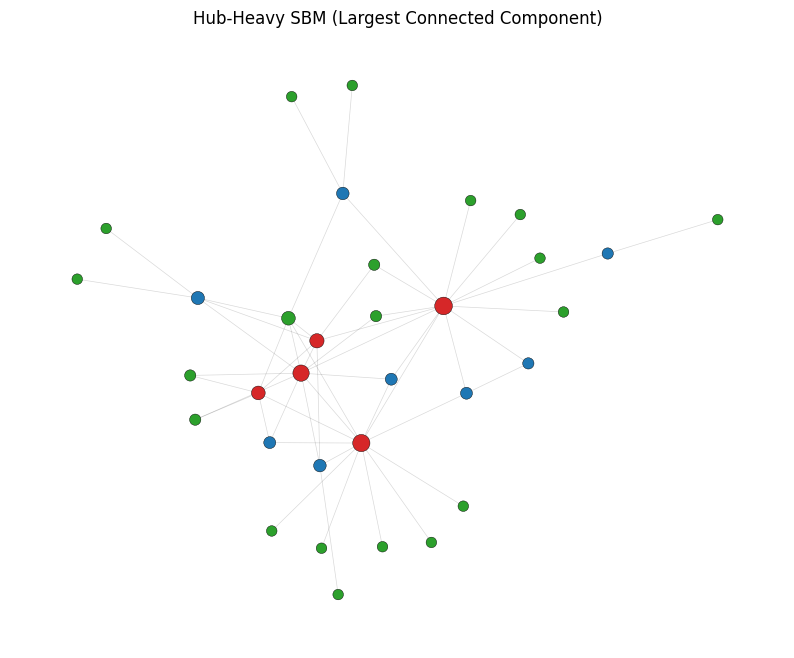

In [194]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ---- Extract largest connected component
if not nx.is_connected(G):
    largest_cc_nodes = max(nx.connected_components(G), key=len)
    G_vis = G.subgraph(largest_cc_nodes).copy()
else:
    G_vis = G

print("Original nodes:", G.number_of_nodes())
print("LCC nodes:", G_vis.number_of_nodes())

# ---- Layout
pos = nx.spring_layout(G_vis, seed=42, k=0.15)

# ---- Role colors
role_colors = {
    "core": "#d62728",
    "mid": "#1f77b4",
    "periphery": "#2ca02c"
}

roles = nx.get_node_attributes(G_vis, "role")
node_colors = [role_colors[roles[n]] for n in G_vis.nodes()]

# ---- Node sizes by degree
degrees = dict(G_vis.degree())
node_sizes = [50 + 8 * degrees[n] for n in G_vis.nodes()]

# ---- Draw
plt.figure(figsize=(10, 8))

nx.draw_networkx_edges(
    G_vis,
    pos,
    alpha=0.15,
    width=0.5
)

nx.draw_networkx_nodes(
    G_vis,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=0.3
)

plt.title("Hub-Heavy SBM (Largest Connected Component)")
plt.axis("off")
plt.show()

### Demo Experiment

In [195]:
from cfmm_routing.sbm import build_market_config_from_graph
from cfmm_routing.config import RoutingConfig, SweepConfig
from cfmm_routing.harness import run_sweep

market_cfg = build_market_config_from_graph(G)

In [196]:
### build market 

### build trade size 

def make_trade_sizes(max_size: float = 1_000.0, n: int = 100):
    xs = np.unique(np.round(
        np.logspace(np.log10(1.0), np.log10(max_size), n)
    ).astype(float))
    return tuple(xs.tolist())

trade_sizes = make_trade_sizes()

### build routing 
# routing_cfg = RoutingConfig(solver="CLARABEL", 
#                             solver_opts={
#                                 "verbose": True,
#                             },)

# routing_cfg = RoutingConfig(solver="ECOS", 
#                             solver_opts={
#                                 "verbose": True,
#                             },)

# from cfmm_routing.config import RoutingConfig

routing_cfg = RoutingConfig(
    solver="SCS",
    solver_opts={
        "max_iters": 50_000,
        "eps": 1e-5,
        "verbose": True,
        "acceleration_lookback": 10,

    },
)

In [197]:
### Define Category Functions 
roles = nx.get_node_attributes(G, "token_type")

# build mapping token_type -> list of nodes
from collections import defaultdict

token_nodes = defaultdict(list)
for node, t in roles.items():
    token_nodes[t].append(node)

print({k: len(v) for k, v in token_nodes.items()})

def get_pairs(t1, t2):
    nodes1 = token_nodes[t1]
    nodes2 = token_nodes[t2]

    pairs = []

    if t1 == t2:
        for i in range(len(nodes1)):
            for j in range(i+1, len(nodes1)):
                pairs.append((nodes1[i], nodes1[j]))
    else:
        for i in nodes1:
            for j in nodes2:
                if i < j:
                    pairs.append((i, j))
                else:
                    pairs.append((j, i))

    return list(set(pairs))

{np.str_('alt'): 23, np.str_('stable'): 6, np.str_('meme'): 14, np.str_('major'): 7}


In [198]:
from collections import Counter

ptype_counts = Counter([p.ptype for p in market_cfg.pools])
print("ptype_counts:", ptype_counts)

def bad_pool(p):
    if p.liquidity <= 0:
        return "nonpositive_liquidity"
    # fee is typically required everywhere in your experiments
    if "fee" not in p.params:
        return "missing_fee"
    if p.ptype == "curve" and "A" not in p.params:
        return "missing_A"
    if p.ptype == "bal_wgm" and (("w_i" not in p.params) or ("w_j" not in p.params)):
        return "missing_weights"
    return None

bad = [(p.uid, p.ptype, bad_pool(p), p.params) for p in market_cfg.pools if bad_pool(p)]
print("bad pools:", len(bad))
print("first 10 bad:", bad[:10])

ptype_counts: Counter({'univ2': 53})
bad pools: 0
first 10 bad: []


In [211]:
from cfmm_routing.market import build_market

category = ("stable", "stable")

pairs = get_pairs(*category)
pairs = [p for p in pairs if reachable(p[0], p[1])]  # component-based reachability

print("Number of pairs:", len(pairs))

mkt = build_market(market_cfg)  # still fine to build; you might use it later


pi_curves = []
dxs_ref = None

for (i, j) in pairs:

    print(f"Asset out: {i}, Asset out: {j}")
    sweep_cfg = SweepConfig(in_asset=i, out_asset=j, dx_grid=trade_sizes)

    res = run_sweep(
        market_cfg=market_cfg,
        routing_cfg=routing_cfg,
        sweep_cfg=sweep_cfg
    )

    dxs, dys = res["dxs"], res["dys"]
    if dxs_ref is None:
        dxs_ref = dxs

    pi = [(dx - dy) / dx for dx, dy in zip(dxs, dys)]
    pi_curves.append(pi)

if len(pi_curves) == 0:
    raise RuntimeError("No reachable pairs in this category.")

mean_pi = np.mean(pi_curves, axis=0)

(CVXPY) Mar 01 09:56:16 PM: Your problem has 212 variables, 209 constraints, and 0 parameters.
(CVXPY) Mar 01 09:56:16 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 01 09:56:16 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 01 09:56:16 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 01 09:56:16 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 01 09:56:16 PM: Compiling problem (target solver=SCS).
(CVXPY) Mar 01 09:56:16 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Mar 01 09:56:16 PM: Applying reduction FlipObjective
(CVXPY) Mar 01 09:56:16 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 01 09:56:16 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 01 09:56:17 PM: Applying reduction ConeMatrixStuffing


Number of pairs: 10
Asset out: 3, Asset out: 24
univ2-0:0-21 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-1:3-6 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-2:3-23 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-3:3-24 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-4:4-23 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-5:5-23 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-6:6-8 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-7:6-11 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-8:6-23 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-9:6-32 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-10:6-41 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-11:8-24 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-12:10-23 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-13:11-24 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-14:12-23 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-15:13-35 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-16:15-33 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-17:19-32 univ2 R (2,) D (2,) L (2,) new_R (2,)
univ2-18:19-37 univ2 R

(CVXPY) Mar 01 09:56:17 PM: Applying reduction SCS
(CVXPY) Mar 01 09:56:17 PM: Finished problem compilation (took 3.409e-01 seconds).
(CVXPY) Mar 01 09:56:17 PM: Invoking solver SCS  to obtain a solution.
(CVXPY) Mar 01 09:56:17 PM: Problem status: infeasible
(CVXPY) Mar 01 09:56:17 PM: Optimal value: -inf
(CVXPY) Mar 01 09:56:17 PM: Compilation took 3.409e-01 seconds
(CVXPY) Mar 01 09:56:17 PM: Solver (including time spent in interface) took 1.350e-03 seconds


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.8 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 265, constraints m: 580
cones: 	  z: primal zero / dual free vars: 1
	  l: linear vars: 420
	  q: soc vars: 159, qsize: 53
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 50000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 1166, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   gap

RuntimeError: Solve failed at dx=1.0: infeasible {'cvxpy_status': 'infeasible', 'solver': 'SCS', 'is_dcp': True}

In [210]:
mkt = build_market(market_cfg)

print("market_cfg.n_assets:", market_cfg.n_assets)
print("mkt.n_assets:", mkt.n_assets)

print("max asset index in pools:",
      max(max(p.i, p.j) for p in mkt.pools))

market_cfg.n_assets: 50
mkt.n_assets: 50
max asset index in pools: 46


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(dxs_ref, mean_pi)
plt.xscale("log")
plt.xlabel("Trade size")
plt.ylabel("Mean marginal price impact")
plt.title("SBM — Stable → Stable (Single Graph)")
plt.show()

In [ ]:
# ### Monte carlo

# seeds = range(20)
# all_curves = []

# for seed in seeds:
#     role_cfg.seed = seed
#     topology_model = TopologyModel(role_cfg)

#     generator = SBMGenerator(
#         topology_model=topology_model,
#         node_model=node_model,
#         edge_model=edge_model
#     )

#     G = generator.generate()
#     market_cfg = build_market_config_from_sbm(generator)

#     # compute mean_pi for stable-stable
#     all_curves.append(mean_pi)

# all_curves = np.array(all_curves)
# final_mean = all_curves.mean(axis=0)
# std = all_curves.std(axis=0)